# PSO y Evolución Diferencial V.S Algoritmo Genético

- Autor: <span style="color:red">Rodrigo S. Cortez-Madrigal</span>
- web: [https://roicort.github.io](https://roicort.github.io)
- github: [https://github.com/roicort/MetaZoo](https://github.com/roicort/MetaZoo)
- docs: [https://roicort.github.io/MetaZoo/](https://roicort.github.io/MetaZoo/)

In [1]:
import time
import numpy as np
from rich.console import Console
from rich.table import Table
import plotly.io as pio
import plotly.graph_objects as go

from metazoo.bio.darwin import ParticleSwarmOptimizer
from metazoo.bio.evolutionary import DifferentialEvolution
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import crossover, mutation, selection
from metazoo.gym.mono import Function
from metazoo.gym.combinatorial import TSP, NQueens
from metazoo.bio.utils import encoding

pio.renderers.default = "png" # Or "jupyterlab"

## Parametricos

In [2]:
def plot(fitness_function, bounds, dim=1, num_points=100, population=None, mode='surface', colorscale='Viridis', labels=None) -> go.Figure:
    metadata = getattr(fitness_function, 'metadata', {}).get(fitness_function.__name__, None)
    title = f'${{\\text{{{fitness_function.__name__.capitalize()} function }}:{metadata["formula"]}}}$' if metadata else f'{fitness_function.__name__.capitalize()} function'
    subtitle = f'Bounds: {bounds}' if bounds else ""
    func = fitness_function.__call__
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

    if dim == 1:
        if isinstance(bounds[0], (tuple, list)):
            x_bounds = bounds[0]
        else:
            x_bounds = bounds
        x = np.linspace(x_bounds[0], x_bounds[1], num_points)
        y = np.array([func(np.array([xi])) for xi in x])
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Function'))
        if population is not None:
            if labels is None and population.shape[0] == 3:
                labels = ['PSO', 'DE', 'GA']
            for i, ind in enumerate(population):
                label = labels[i] if labels and i < len(labels) else 'Individual'
                color = colors[i % len(colors)]
                pop_x = ind[0]
                pop_y = func(np.array([pop_x]))
                fig.add_trace(go.Scatter(x=[pop_x], y=[pop_y], mode='markers', name=label, marker=dict(color=color, size=10)))
        fig.update_layout(title=title, xaxis_title='x', yaxis_title='f(x)')
    elif dim == 2:
        if isinstance(bounds[0], (tuple, list)) and isinstance(bounds[1], (tuple, list)):
            x_bounds = bounds[0]
            y_bounds = bounds[1]
        else:
            x_bounds = y_bounds = bounds
        x = np.linspace(x_bounds[0], x_bounds[1], num_points)
        y = np.linspace(y_bounds[0], y_bounds[1], num_points)
        X, Y = np.meshgrid(x, y)
        Z = np.array([func(np.array([xi, yi])) for xi, yi in zip(np.ravel(X), np.ravel(Y))])
        Z = Z.reshape(X.shape)
        fig = go.Figure()
        if mode == 'surface':
            fig.add_trace(go.Surface(z=Z, x=X, y=Y, colorscale=colorscale, opacity=0.7, name='Function'))
            if population is not None:
                if labels is None and population.shape[0] == 3:
                    labels = ['PSO', 'DE', 'GA']
                for i, ind in enumerate(population):
                    label = labels[i] if labels and i < len(labels) else 'Individual'
                    color = colors[i % len(colors)]
                    pop_x = ind[0]
                    pop_y = ind[1]
                    pop_z = func(np.array([pop_x, pop_y]))
                    fig.add_trace(go.Scatter3d(x=[pop_x], y=[pop_y], z=[pop_z], mode='markers', name=label, marker=dict(color=color, size=6)))
            fig.update_layout(title=title, scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='f(x, y)'))
        elif mode == 'contour':
            fig.add_trace(go.Contour(z=Z, x=x, y=y, colorscale=colorscale, name='Function'))
            if population is not None:
                if labels is None and population.shape[0] == 3:
                    labels = ['PSO', 'DE', 'GA']
                for i, ind in enumerate(population):
                    label = labels[i] if labels and i < len(labels) else 'Individual'
                    color = colors[i % len(colors)]
                    pop_x = ind[0]
                    pop_y = ind[1]
                    fig.add_trace(go.Scatter(x=[pop_x], y=[pop_y], mode='markers', name=label, marker=dict(color=color, size=10)))
            fig.update_layout(title=title, xaxis_title='x', yaxis_title='y')
        else:
            raise ValueError("Mode should be 'surface' or 'contour'.")
    else:
        raise ValueError('Only 1D or 2D functions are supported for plotting.')
    
    fig.update_layout(
        title={'text': title, 'x':0.5},
        annotations=[dict(text=subtitle, x=0.5, y=-0.15, showarrow=False, xref="paper", yref="paper", xanchor='center', yanchor='top')],
        legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.2),
        showlegend=True
    )
    return fig

In [3]:
targets = ['Sphere', 'Bukin', 'Himmelblau', 'EggHolder', 'Easom']

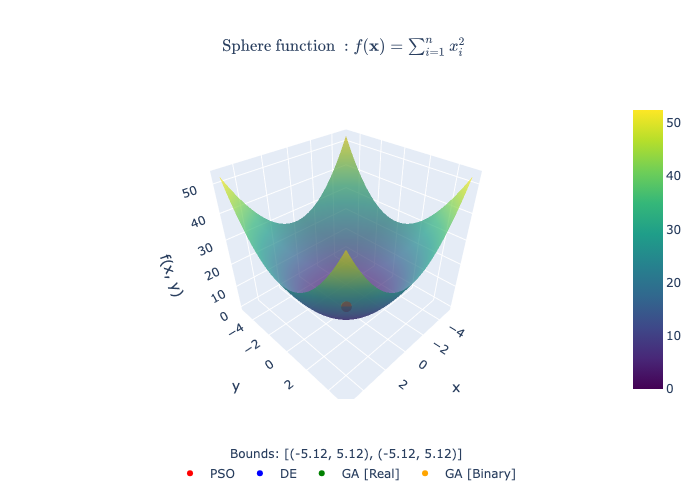

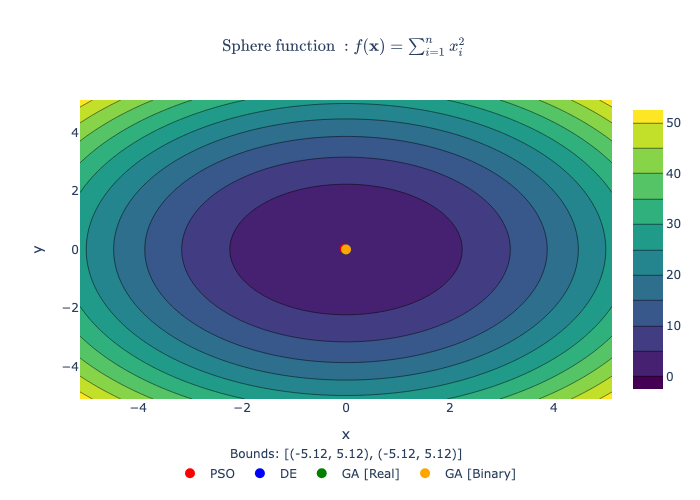

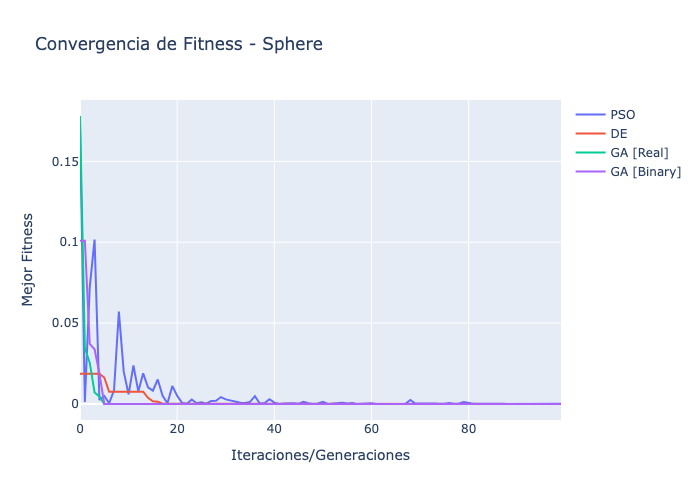

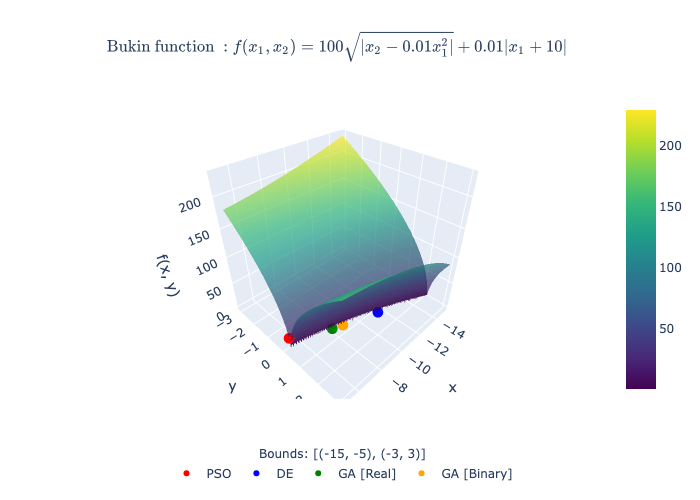

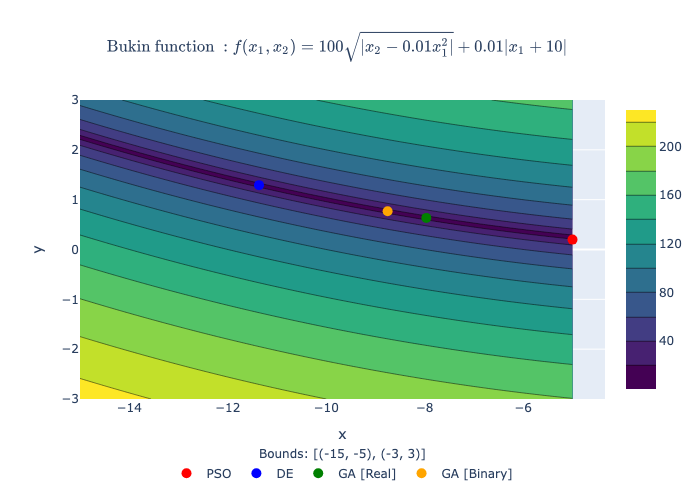

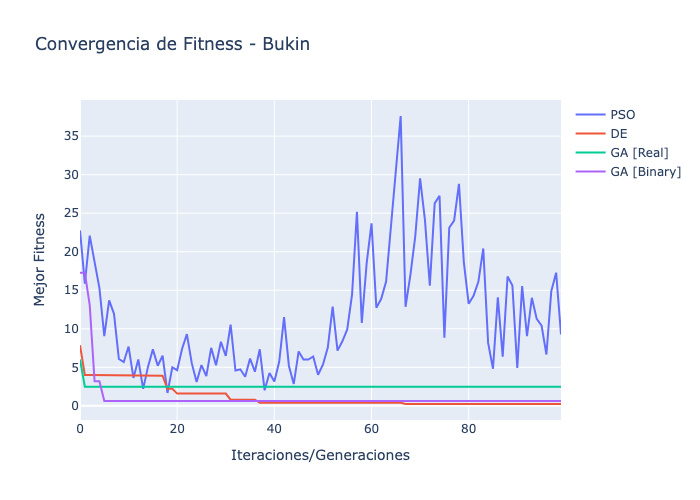

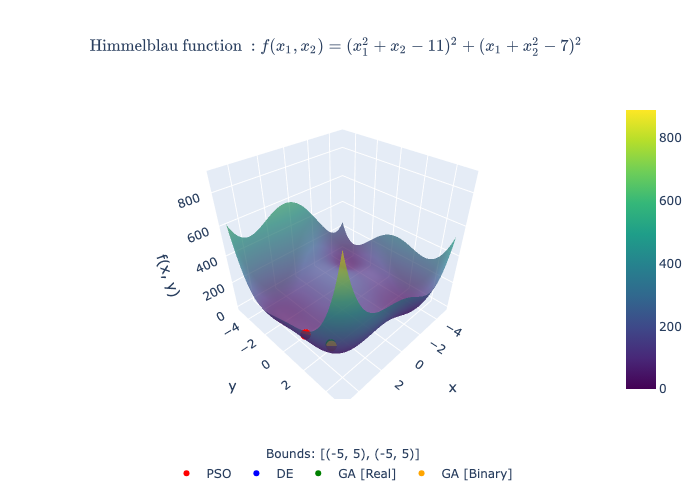

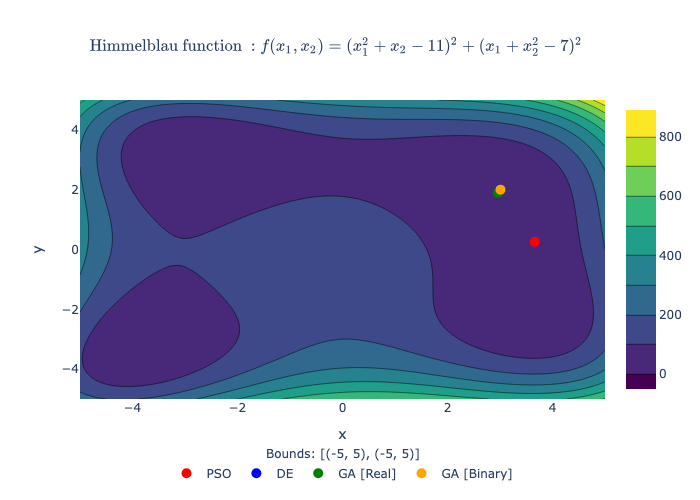

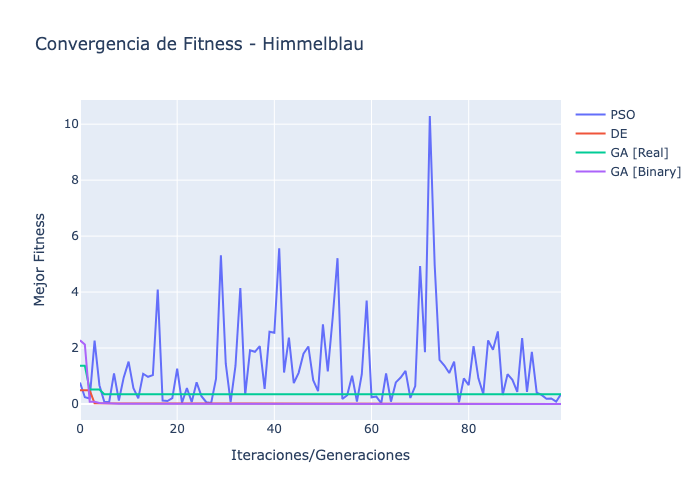

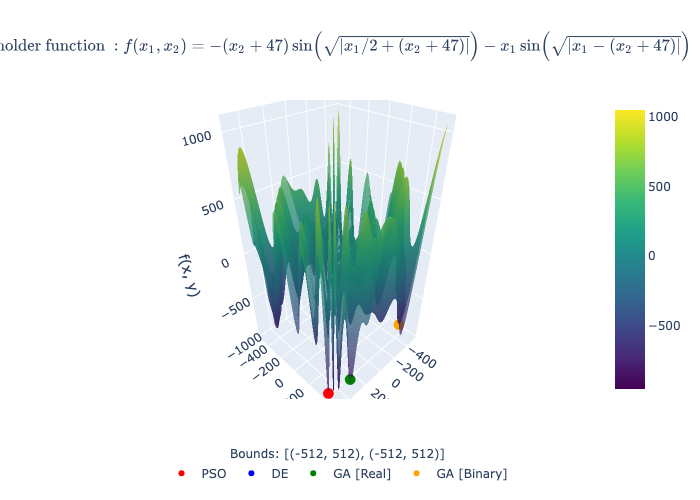

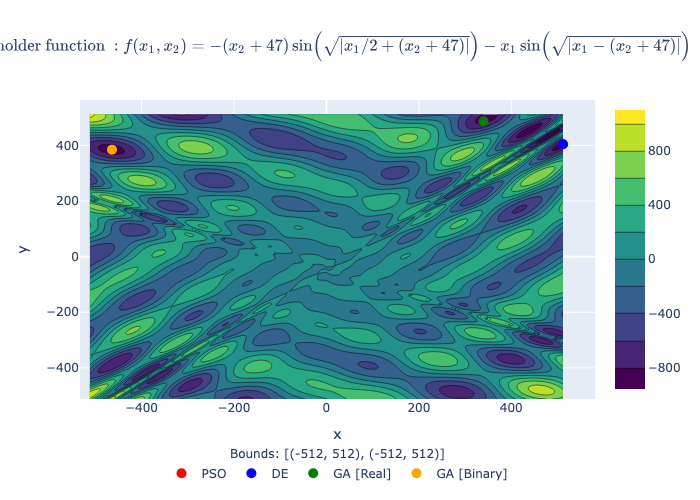

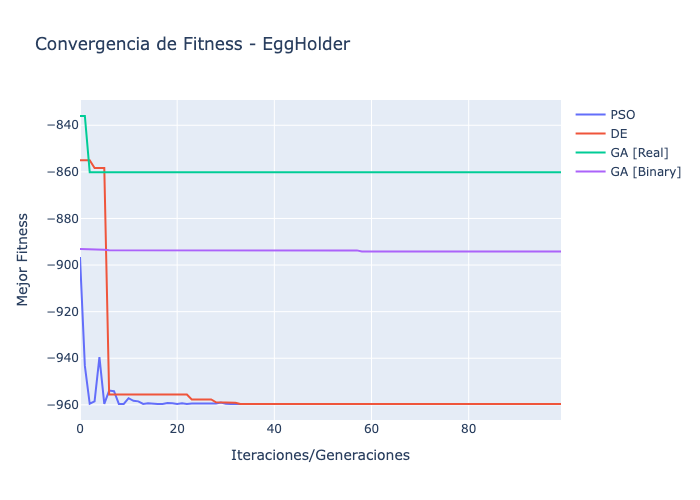

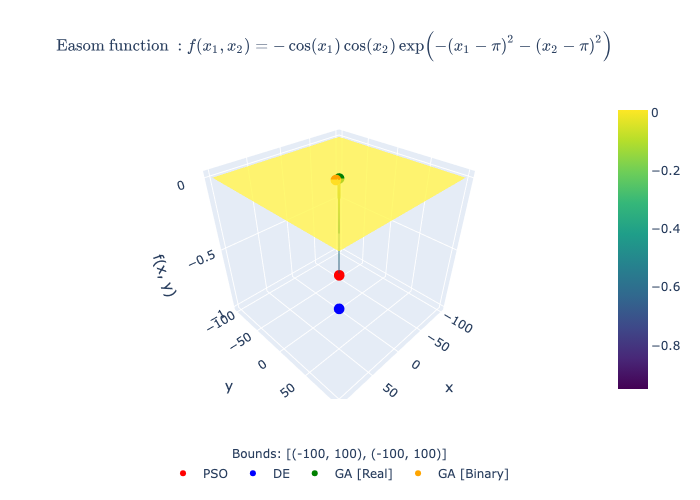

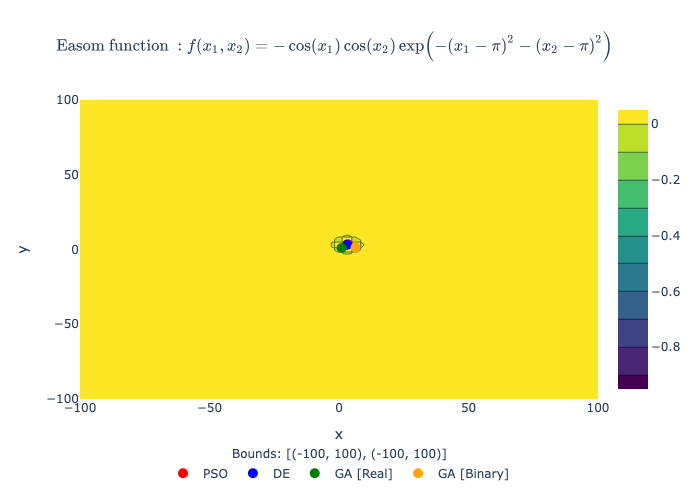

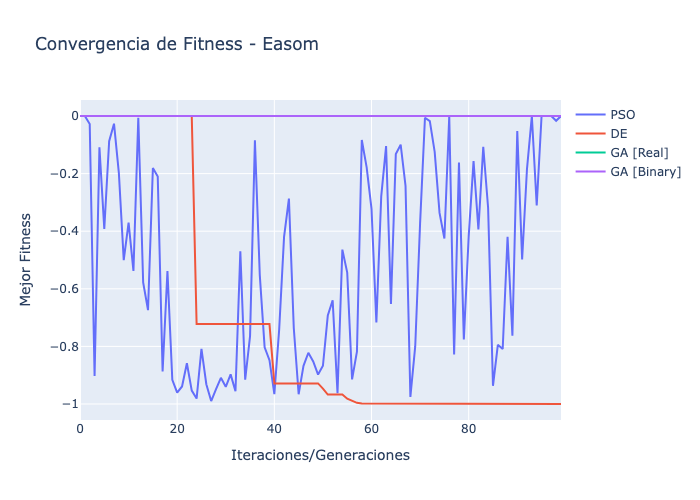

                         Comparación de Algoritmos                         
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Función    ┃ Algoritmo   ┃ Mejor Individuo ┃ Mejor Fitness ┃ Tiempo (s) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Sphere     │ PSO         │ [-0.02  0.02]   │ 0.0001113     │ 0.0626     │
│ Sphere     │ DE          │ [-0. -0.]       │ 1.013e-15     │ 0.1696     │
│ Sphere     │ GA [Real]   │ [0. 0.]         │ 0             │ 0.0943     │
│ Sphere     │ GA [Binary] │ [ 0. -0.]       │ 1.953e-07     │ 0.1198     │
│ Bukin      │ PSO         │ [-5.   0.2]     │ 9.263         │ 0.0670     │
│ Bukin      │ DE          │ [-11.37   1.29] │ 0.2388        │ 0.1935     │
│ Bukin      │ GA [Real]   │ [-7.97  0.63]   │ 2.475         │ 0.1011     │
│ Bukin      │ GA [Binary] │ [-8.75  0.77]   │ 0.6211        │ 0.1348     │
│ Himmelblau │ PSO         │ [3.66 0.26]     │ 0.3557        │ 0.0514     │
│ Himmelblau │ DE          │ [3. 2.]         │ 1.174e-08     │ 0.1864     │
│ Himmelblau │ GA [Real]   │ [2.96 1.89]     │ 0.3483        │ 0.0803     │
│ Himmelblau │ GA [Binary] │ [3.01 2.  ]     │ 0.003468      │ 0.1308     │
│ EggHolder  │ PSO         │ [512.   404.24] │ -959.6        │ 0.0699     │
│ EggHolder  │ DE          │ [512.   404.23] │ -959.6        │ 0.2413     │
│ EggHolder  │ GA [Real]   │ [339.97 487.25] │ -860.2        │ 0.0966     │
│ EggHolder  │ GA [Binary] │ [-464.  385.]   │ -894.2        │ 0.1347     │
│ Easom      │ PSO         │ [3.37 3.58]     │ -2.653e-09    │ 0.0659     │
│ Easom      │ DE          │ [3.14 3.14]     │ -1            │ 0.1757     │
│ Easom      │ GA [Real]   │ [1. 1.]         │ -3.031e-05    │ 0.0911     │
│ Easom      │ GA [Binary] │ [6.36 1.32]     │ -2.812e-07    │ 0.1272     │
└────────────┴─────────────┴─────────────────┴───────────────┴────────────┘

In [8]:
console = Console()

table = Table(title="Comparación de Algoritmos")
table.add_column("Función", style="bold cyan")
table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Individuo", style="white")
table.add_column("Mejor Fitness", style="green")
table.add_column("Tiempo (s)", style="yellow")

for target in targets:
    fitness_function = Function(target, reverse=False)
    encoder = encoding.Real(bounds=fitness_function.bounds)

    # PSO
    pso = ParticleSwarmOptimizer(
        fitness_function,
        encoder=encoder,
        population_size=90,
        inertia=0.8,
        cognitive=1.5,
        social=1.5,
        minimize=True,
    )
    start = time.time()
    pso.run(iterations=100, verbose=False)
    pso_time = time.time() - start

    # DE
    de = DifferentialEvolution(
        fitness_function,
        encoder=encoder,
        population_size=90,
        F=0.8,
        CR=0.9,
        minimize=True,
    )
    start = time.time()
    de.run(generations=100, verbose=False)
    de_time = time.time() - start

    # GA [Real]
    ga = GeneticAlgorithm(
        fitness_function,
        encoder=encoder,
        crossover_function=crossover.onepoint,
        mutation_function=mutation.gaussian,
        selection_function=selection.tournament,
        population_size=90,
        mutation_rate=0.01,
        crossover_rate=0.7,
        elitism=0.1,
        minimize=True,
    )
    start = time.time()
    ga.run(generations=100, verbose=False)
    ga_time = time.time() - start

    # GA [Binary]

    gab = GeneticAlgorithm(
        fitness_function,
        encoder=encoding.Binary(precision=3, bounds=fitness_function.bounds),
        crossover_function=crossover.onepoint,
        mutation_function=mutation.flip_bit,
        selection_function=selection.tournament,
        population_size=90,
        mutation_rate=0.01,
        crossover_rate=0.7,
        elitism=0.1,
        minimize=True,
    )
    start = time.time()
    gab.run(generations=100, verbose=False)
    gab_time = time.time() - start

    # Agrega resultados a la tabla
    table.add_row(target, "PSO", str(np.round(pso.global_best_position, 2)), f"{pso.best_fitness:.4g}", f"{pso_time:.4f}")
    table.add_row(target, "DE", str(np.round(de.best_individual, 2)), f"{de.best_fitness:.4g}", f"{de_time:.4f}")
    table.add_row(target, "GA [Real]", str(np.round(ga.best_individual, 2)), f"{ga.best_fitness:.4g}", f"{ga_time:.4f}")
    table.add_row(target, "GA [Binary]", str(np.round(gab.best_individual, 2)), f"{gab.best_fitness:.4g}", f"{gab_time:.4f}")
    
    gabest = ga.best_individual
    gabbest = gab.best_individual
    debest = de.best_individual
    psobest = pso.global_best_position

    labels = ['PSO', 'DE', 'GA [Real]', 'GA [Binary]']
    fig1 = plot(fitness_function, fitness_function.bounds, dim=2, num_points=300, mode='surface', population=np.array([psobest, debest, gabest, gabbest]), labels=labels)
    fig2 = plot(fitness_function, fitness_function.bounds, dim=2, num_points=300, mode='contour', population=np.array([psobest, debest, gabest, gabbest]), labels=labels)

    fig1.show()
    fig2.show()

    # Plot fitness convergence
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
    fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
    fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA [Real]'))
    fig.add_trace(go.Scatter(y=gab.best_history, mode='lines', name='GA [Binary]'))
    fig.update_layout(title=f'Convergencia de Fitness - {target}',
                      xaxis_title='Iteraciones/Generaciones',
                      yaxis_title='Mejor Fitness')
    fig.show()

console.print(table)

Todos los algoritmos fueron ejecutados con los siguientes parámetros:
- Tamaño de población: 90 para todos los algoritmos.
- Número de generaciones/iteraciones: 100 para todos los algoritmos.
- Tasa de mutación: 0.01 para GA.
- Tasa de cruce: 0.7 para GA.
- Elitismo: 10% para GA.
- PSO: inercia 0.8, coeficiente cognitivo 1.5, coeficiente social 1.5.  

Comparando el desempeño de los algoritmos de Optimización por Enjambre de Partículas (PSO) y Evolución Diferencial (DE) contra un Algoritmo Genético (GA) en funciones de optimización continua (tanto en su versión real como binaria) para un conjunto de funciones objetivo, observamos lo siguiente:

- PSO y DE tienden a converger más rápidamente que GA en la mayoría de las funciones objetivo.
- PSO tiende a encontrar soluciones cercanas al óptimo global con mayor consistencia que GA.
- DE muestra un excelente desempeño, pero es igualmente sensible a la configuración de sus parámetros.
- GA, especialmente en su versión binaria, puede tener dificultades para alcanzar la misma calidad de solución que PSO y DE en un número limitado de generaciones. Esto se debe a la naturaleza discreta de la representación binaria, que puede limitar la exploración del espacio de soluciones.

En problemas paramétricos continuos, PSO y DE tiene una ventaja clara sobre GA.

- PSO explota rápidamente regiones prometedoras gracias a la atracción al mejor global y local.
- DE explora muy eficientemente combinando diferencias entre soluciones.
- Esto permite menos evaluaciones de función y una convergencia más suave y dirigida hacia el óptimo global en comparación con los GA.
- Los GA tienden a ser más ruidosos y necesitan más evaluaciones para afinar la solución.
- Los GAs requiere una selección cuidadosa de operadores y parámetros para evitar la convergencia prematura y al menos en los experimentos realizados elitismo fuerte.


## Combinatorios

### TSP

In [5]:
tsp = TSP.Berlin52()
encoder = encoding.Permutation(permutation_size=tsp.dimension)

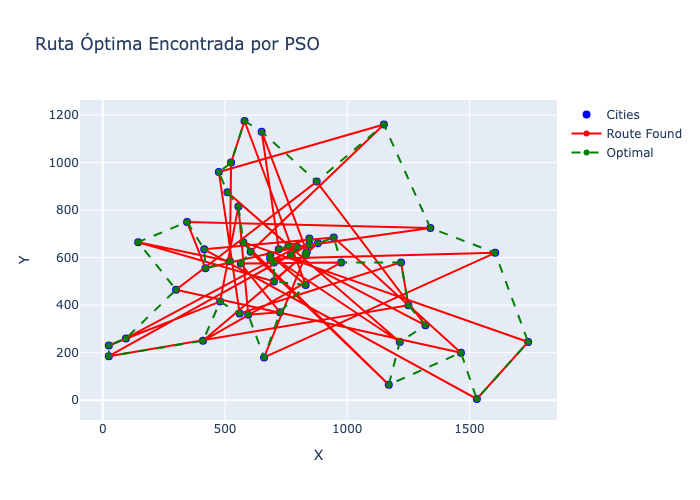

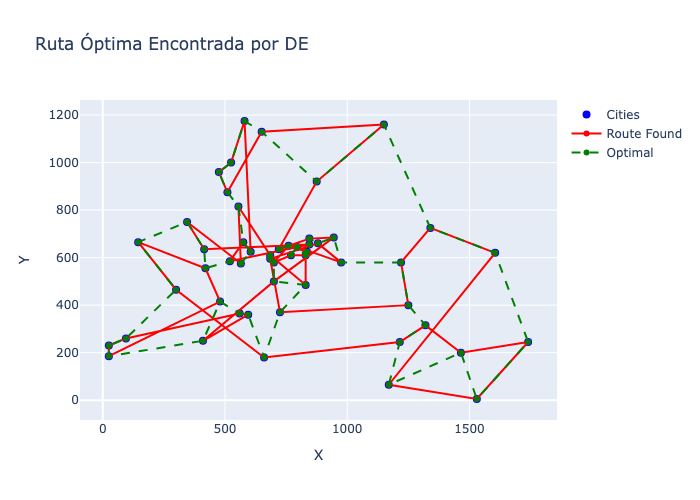

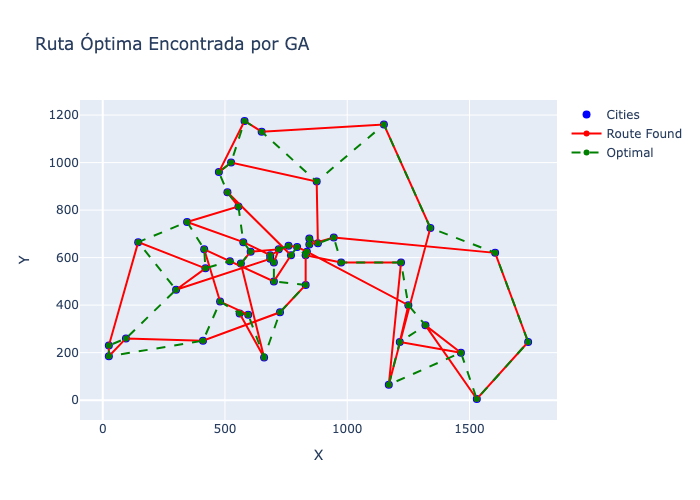

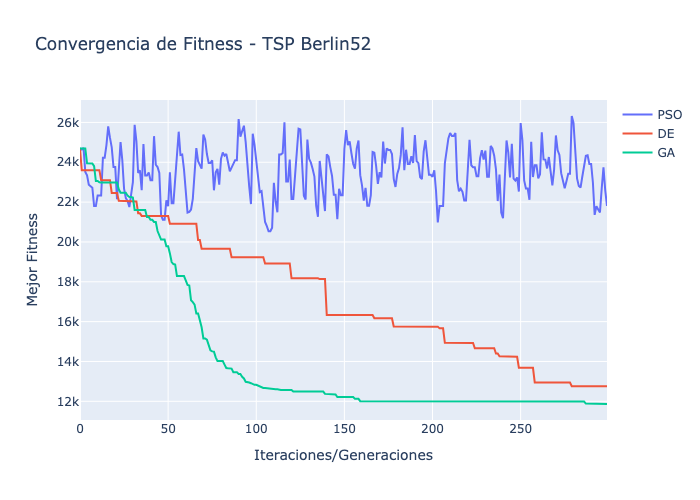

                    Comparación de Algoritmos - TSP Berlin52                    
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Algoritmo ┃ Mejor Fitness      ┃ Optimo ┃ Diferencia con Óptimo ┃ Tiempo (s) ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ PSO       │ 21804.256198467996 │ 7542.0 │ 14262.256198467996    │ 5.5121     │
│ DE        │ 12759.281320883718 │ 7542.0 │ 5217.281320883718     │ 7.6424     │
│ GA        │ 11865.495986647116 │ 7542.0 │ 4323.495986647116     │ 1.7117     │
└───────────┴────────────────────┴────────┴───────────────────────┴────────────┘

In [6]:
console = Console()

table = Table(title="Comparación de Algoritmos - TSP Berlin52")

table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Fitness", style="green")
table.add_column("Optimo", style="green")
table.add_column("Diferencia con Óptimo", style="red")
table.add_column("Tiempo (s)", style="yellow")

# PSO
pso = ParticleSwarmOptimizer(
    tsp,
    encoder=encoder,
    population_size=200,
    inertia=0.7,
    cognitive=1.0,
    social=1.5,
    minimize=True,
)
start = time.time()
pso.run(iterations=300, verbose=False)
pso_time = time.time() - start

# DE

de = DifferentialEvolution(
    tsp,
    encoder=encoder,
    population_size=200,
    F=0.8,
    CR=0.9,
    minimize=True,
)
start = time.time()
de.run(generations=300, verbose=False)
de_time = time.time() - start

# GA

ga = GeneticAlgorithm(
    tsp,
    encoder=encoder,
    crossover_function=crossover.PMX,
    mutation_function=mutation.swap,
    selection_function=selection.tournament,
    population_size=200,
    mutation_rate=0.01,
    crossover_rate=0.7,
    elitism=0.1,
    minimize=True,
)
start = time.time()
ga.run(generations=300, verbose=False)
ga_time = time.time() - start

# Agrega resultados a la tabla
table.add_row("PSO", f"{pso.best_fitness}", f"{tsp.optimal_value}", f"{pso.best_fitness - tsp.optimal_value}", f"{pso_time:.4f}")
table.add_row("DE", f"{de.best_fitness}", f"{tsp.optimal_value}", f"{de.best_fitness - tsp.optimal_value}", f"{de_time:.4f}")
table.add_row("GA", f"{ga.best_fitness}", f"{tsp.optimal_value}", f"{ga.best_fitness - tsp.optimal_value}", f"{ga_time:.4f}")

# Mostrar rutas óptimas encontradas
fig = tsp.plot(show_optimal=True, solution=pso.global_best_position)
fig.update_layout(title='Ruta Óptima Encontrada por PSO')
fig.show()
fig = tsp.plot(show_optimal=True, solution=de.best_individual)
fig.update_layout(title='Ruta Óptima Encontrada por DE')
fig.show()
fig = tsp.plot(show_optimal=True, solution=ga.best_individual)
fig.update_layout(title='Ruta Óptima Encontrada por GA')
fig.show()

# Plot fitness convergence
fig = go.Figure()
fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA'))
fig.update_layout(title='Convergencia de Fitness - TSP Berlin52',
                  xaxis_title='Iteraciones/Generaciones',
                  yaxis_title='Mejor Fitness')
fig.show()

console.print(table)

En el problema del viajante (TSP), claramente GA supera a PSO y DE en términos de calidad de la solución. GA es más adecuado para problemas combinatorios como TSP debido a su capacidad para manejar representaciones discretas y explorar eficientemente el espacio de soluciones mediante operadores genéticos como la selección, el cruce y la mutación. 

Por otro lado, PSO que estaba diseñado principalmente para optimización continua, tuvo dificultades para adaptarse a la naturaleza discreta del TSP, lo que resultó en soluciones subóptimas. No obstante DE mostró un mejor desempeño que PSO en este caso, casi alcanzando la calidad de solución de GA, pero aun mayor costo computacional.

Me parece que la ventaja principal de los GA es sus operadores permiten:

- Recombinar rutas buenas para generar nuevas combinaciones prometedoras
- Preservar estructuras locales útiles (subciclos buenos)
- Mantener diversidad mediante mutulación controlada

En cambio, en PSO y DE adaptados a este dominio, la exploración suele ser menos eficiente porque la noción de “distancia” entre permutaciones no es clara y los movimientos en el espacio de soluciones no aprovechan las buenas estructuras existentes.

### N-Queens

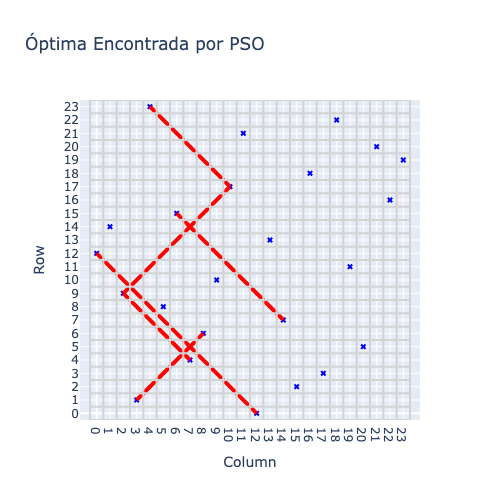

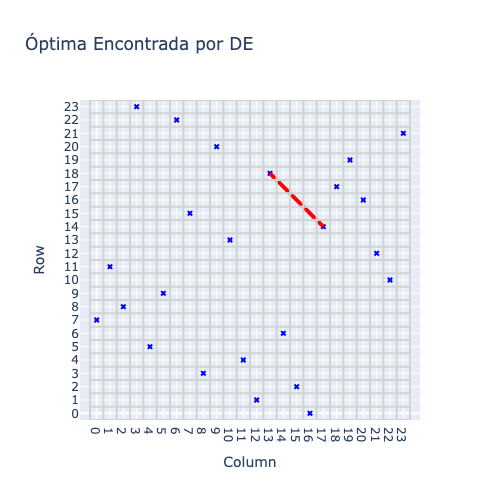

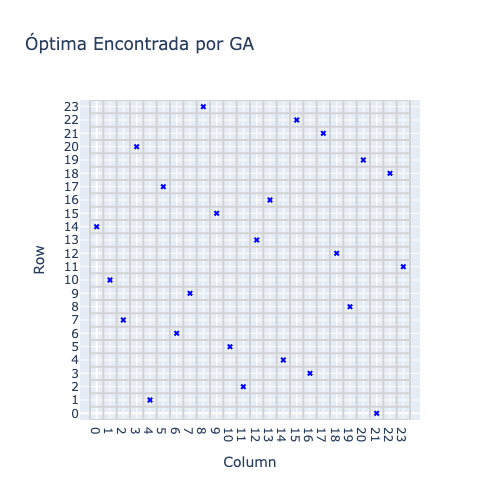

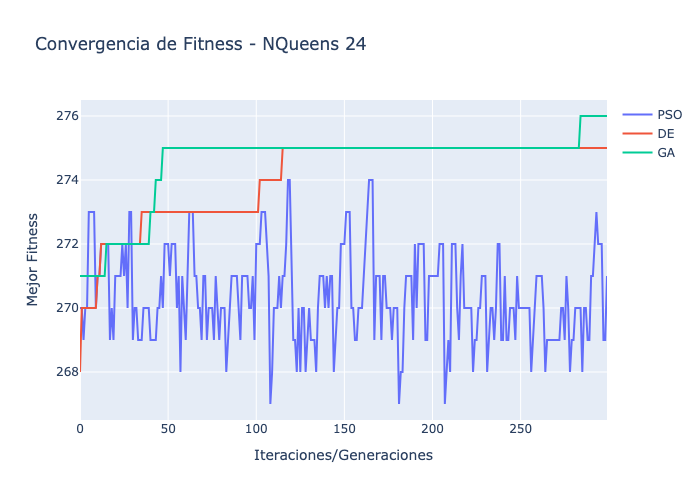

  Comparación de Algoritmos - NQueens 24  
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Algoritmo ┃ Mejor Fitness ┃ Tiempo (s) ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ PSO       │ 271.0         │ 5.8642     │
│ DE        │ 275.0         │ 10.8273    │
│ GA        │ 276.0         │ 4.4092     │
└───────────┴───────────────┴────────────┘

In [7]:
nqueens = NQueens(n=24)
encoder = encoding.Permutation(permutation_size=nqueens.n)

console = Console()

table = Table(title="Comparación de Algoritmos - NQueens 24")

table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Fitness", style="green")
table.add_column("Tiempo (s)", style="yellow")

# PSO
pso = ParticleSwarmOptimizer(
    nqueens,
    encoder=encoder,
    population_size=200,
    inertia=0.7,
    cognitive=1.0,
    social=1.5,
    minimize=False,
)
start = time.time()
pso.run(iterations=300, verbose=False)
pso_time = time.time() - start

# DE

de = DifferentialEvolution(
    nqueens,
    encoder=encoder,
    population_size=200,
    F=0.8,
    CR=0.9,
    minimize=False,
)
start = time.time()
de.run(generations=300, verbose=False)
de_time = time.time() - start

# GA

ga = GeneticAlgorithm(
    nqueens,
    encoder=encoder,
    crossover_function=crossover.PMX,
    mutation_function=mutation.swap,
    selection_function=selection.tournament,
    population_size=200,
    mutation_rate=0.01,
    crossover_rate=0.7,
    elitism=0.1,
    minimize=False,
)
start = time.time()
ga.run(generations=300, verbose=False)
ga_time = time.time() - start

# Agrega resultados a la tabla
table.add_row("PSO", f"{pso.best_fitness}", f"{pso_time:.4f}")
table.add_row("DE", f"{de.best_fitness}", f"{de_time:.4f}")
table.add_row("GA", f"{ga.best_fitness}", f"{ga_time:.4f}")

# Mostrar rutas óptimas encontradas
fig = nqueens.plot(solution=pso.global_best_position)
fig.update_layout(title='Óptima Encontrada por PSO')
fig.show()
fig = nqueens.plot(solution=de.best_individual)
fig.update_layout(title='Óptima Encontrada por DE')
fig.show()
fig = nqueens.plot(solution=ga.best_individual)
fig.update_layout(title='Óptima Encontrada por GA')
fig.show()

# Plot fitness convergence
fig = go.Figure()
fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA'))
fig.update_layout(title='Convergencia de Fitness - NQueens 24',
                  xaxis_title='Iteraciones/Generaciones',
                  yaxis_title='Mejor Fitness')
fig.show()

console.print(table)

Para el problema de las N-Reinas, el Algoritmo Genético (GA) nuevamente demostró ser superior a PSO y DE en términos de calidad de la solución. GA es capaz de explorar eficazmente el espacio de soluciones discretas del problema N-Reinas mediante la aplicación de operadores genéticos, lo que le permite encontrar configuraciones válidas de reinas con mayor eficiencia. Por otro lado, PSO y DE enfrentan desafíos similares a los observados en el TSP debido a la naturaleza discreta del problema, lo que limita su capacidad para encontrar soluciones óptimas.

En este caso en los algoritmos genéticos podemos ajustar la presión selectiva, controlar diversidad,
aplicar elitismo moderado, lo que da un balance natural entre explorar nuevas rutas y mejorar las buenas. (De hecho sin el elitismo los GA son menos efectivos y superados por PSO y DE). Si lo pensamos PSO es un algoritmo muy explotador, y DE depende mucho de la diversidad inicial.

Por lo mismo la convergencia suele ser muy rápida, pero puede converger prematuramente a soluciones subóptimas. Los individuos tienden a seguir a los mejores demasiado pronto, perdiendo diversidad y capacidad de exploración, de aqui la importancia de ajustar la inercia y los coeficientes cognitivos/sociales. El DE por otro lado puede estancarse cuando las permutaciones son muy similares, pero aun así logra mejores resultados que PSO en este dominio.